In [13]:
import torch
import numpy as np
import pandas as pd
import scipy.sparse as sp
import os
from tqdm import tqdm, trange
import datetime

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,cohen_kappa_score

# from scipy import interp

from numpy import interp
import matplotlib.pyplot as plt

from scipy.special import comb, perm

plt.style.use('default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [14]:
def auroc(prob,label):
    y_true=label
    y_scores=prob
    fpr,tpr,thresholds=roc_curve(y_true,y_scores)
    auroc_score=auc(fpr,tpr)
    return auroc_score,fpr,tpr

def auprc(prob,label):
    y_true=label
    y_scores=prob
    precision,recall,thresholds=precision_recall_curve(y_true,y_scores)
    auprc_score=auc(recall,precision)
    return auprc_score,precision,recall

def get_evaluation_metrics(predlabel,labels):
    predlabel_s = predlabel
    labels_s = labels
    acc = accuracy_score(labels_s, predlabel_s)
    precision = precision_score(labels_s, predlabel_s)
    recall = recall_score(labels_s, predlabel_s)
    f1 = f1_score(labels_s, predlabel_s)
    confusion = confusion_matrix(labels_s, predlabel_s)
    TP = confusion[1, 1]
    TN = confusion[0, 0]
    FP = confusion[0, 1]
    FN = confusion[1, 0]

    specificity = TN / float(TN+FP)
    kappa = cohen_kappa_score(labels_s, predlabel_s)

    return acc, precision, recall, f1, specificity, kappa


def calc_metrics(df, size_list):
    AUC, AUPR, Acc, Prec, Recall, F1 = [], [], [], [], [], []
    ### 分size计算模型性能
    for s in size_list:
        df_tmp = df.loc[df.Size == s]

        labels = df_tmp['Label']
        outputs = df_tmp['Pred']
        predlabels = (df_tmp['Pred'] > 0.5).astype(int)
        auc_, fpr, tpr = auroc(outputs, labels) 
        aupr, precision_, recall_ = auprc(outputs, labels)
        acc, prec, rec, f1, specifity, kappa = get_evaluation_metrics(predlabels, labels)

        AUC.append(auc_)
        AUPR.append(aupr)
        Acc.append(acc)
        Prec.append(prec)
        Recall.append(rec)
        F1.append(f1)

    ### 不分size,对所有size一起计算
    labels = df['Label']
    outputs = df['Pred']
    predlabels = (df['Pred'] > 0.5).astype(int)
    auc_, fpr, tpr = auroc(outputs, labels) 
    aupr, precision_, recall_ = auprc(outputs, labels)
    acc, prec, rec, f1, specifity, kappa = get_evaluation_metrics(predlabels, labels)

    AUC.append(auc_)
    AUPR.append(aupr)
    Acc.append(acc)
    Prec.append(prec)
    Recall.append(rec)
    F1.append(f1)

    df_res = pd.DataFrame({'Size': size_list + ['Total'],
                            'AUC': AUC,
                            'AUPR': AUPR,
                            'ACC': Acc,
                            'PREC': Prec,
                            'REC': Recall,
                            'F1': F1})
    return df_res

In [3]:
## HiPore-C_GM12878_1Mb
writer = pd.ExcelWriter('SGMCI_HiPore-C_GM12878_1Mb.Performance.xlsx')

samples = ['HiPore-C_GM12878_1Mb']

chroms = ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
            'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
            'chr21', 'chr22', 'chrX']

NSs = ['RNS', 'BNS', 'SNS', 'MIX']
# NSs = ['RNS', 'BNS', 'SNS', 'MIX'] ### 不同数据不同负样本采样方式的模型性能
size_list = [3, 4, 5, 6, 7, 8, 9, 10]  ###不同order

for sample in samples:
    for chrom in tqdm(chroms):
        mp_tmp = []
        for ns in NSs:
            data = pd.read_table(f'/data/xujs/Project/HiC2PoreC/code/SGMCI/results/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.tsv', sep='\t')
            df_MP = calc_metrics(data, size_list=size_list)
            mp_tmp.append(df_MP)
        df_sample_MP = pd.concat(mp_tmp)
        n = len(size_list) + 1
        df_sample_MP['NS'] = ['RNS']*n + ['BNS']*n + ['SNS']*n + ['MIX']*n
        df_sample_MP = df_sample_MP[['Size', 'NS', 'AUC', 'AUPR', 'ACC', 'PREC', 'REC', 'F1']]
        df_sample_MP.to_excel(writer, sheet_name=chrom, index=False)

writer.save()

100%|██████████| 23/23 [01:48<00:00,  4.71s/it]


In [4]:
## HiPore-C_GM12878_100kb
writer = pd.ExcelWriter('SGMCI_HiPore-C_GM12878_100kb.Performance.xlsx')

samples = ['HiPore-C_GM12878_100kb']

chroms =   ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
            'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
            'chr21', 'chr22', 'chrX']

NSs = ['RNS', 'BNS', 'SNS', 'MIX'] ### 不同数据不同负样本采样方式的模型性能
size_list = [3, 4, 5, 6, 7, 8, 9, 10]  ###不同order

for sample in samples:
    for chrom in tqdm(chroms):
        mp_tmp = []
        for ns in NSs:
            data = pd.read_table(f'/data/xujs/Project/HiC2PoreC/code/SGMCI/results/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.tsv', sep='\t')
            df_MP = calc_metrics(data, size_list=size_list)
            mp_tmp.append(df_MP)
        df_sample_MP = pd.concat(mp_tmp)
        n = len(size_list) + 1
        df_sample_MP['NS'] = ['RNS']*n + ['BNS']*n + ['SNS']*n + ['MIX']*n
        df_sample_MP = df_sample_MP[['Size', 'NS', 'AUC', 'AUPR', 'ACC', 'PREC', 'REC', 'F1']]
        df_sample_MP.to_excel(writer, sheet_name=chrom, index=False)

writer.save()

100%|██████████| 23/23 [02:33<00:00,  6.66s/it]


In [5]:
## HiPore-C_GM12878_5kb
writer = pd.ExcelWriter('SGMCI_HiPore-C_GM12878_5kb.Performance.xlsx')

samples = ['HiPore-C_GM12878_5kb']

chroms =   ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
            'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
            'chr21', 'chr22', 'chrX']

NSs = ['RNS', 'BNS', 'SNS', 'MIX'] ### 不同数据不同负样本采样方式的模型性能
size_list = [3, 4, 5, 6, 7, 8, 9, 10]  ###不同order

for sample in samples:
    for chrom in tqdm(chroms):
        mp_tmp = []
        for ns in NSs:
            data = pd.read_table(f'/data/xujs/Project/HiC2PoreC/code/SGMCI/results/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.tsv', sep='\t')
            df_MP = calc_metrics(data, size_list=size_list)
            mp_tmp.append(df_MP)
        df_sample_MP = pd.concat(mp_tmp)
        n = len(size_list) + 1
        df_sample_MP['NS'] = ['RNS']*n + ['BNS']*n + ['SNS']*n + ['MIX']*n
        df_sample_MP = df_sample_MP[['Size', 'NS', 'AUC', 'AUPR', 'ACC', 'PREC', 'REC', 'F1']]
        df_sample_MP.to_excel(writer, sheet_name=chrom, index=False)

writer.save()

  0%|          | 0/23 [00:00<?, ?it/s]/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/xujs/miniconda3/envs/GLASS/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/data/xujs/miniconda3/envs

In [4]:
def auroc(prob,label):
    y_true=label
    y_scores=prob
    fpr,tpr,thresholds=roc_curve(y_true,y_scores)
    auroc_score=auc(fpr,tpr)
    return auroc_score,fpr,tpr

def auprc(prob,label):
    y_true=label
    y_scores=prob
    precision,recall,thresholds=precision_recall_curve(y_true,y_scores)
    auprc_score=auc(recall,precision)
    return auprc_score,precision,recall

def get_evaluation_metrics(predlabel,labels):
    predlabel_s = predlabel
    labels_s = labels
    acc = accuracy_score(labels_s, predlabel_s)
    precision = precision_score(labels_s, predlabel_s)
    recall = recall_score(labels_s, predlabel_s)
    f1 = f1_score(labels_s, predlabel_s)
    confusion = confusion_matrix(labels_s, predlabel_s)
    TP = confusion[1, 1]
    TN = confusion[0, 0]
    FP = confusion[0, 1]
    FN = confusion[1, 0]

    specificity = TN / float(TN+FP)
    kappa = cohen_kappa_score(labels_s, predlabel_s)

    return acc, precision, recall, f1, specificity, kappa

def stat_runs_metrics(file_dir, dataset, runs=5):
    """
    filedir: file dirs storing 5-CV results
    """
    run_list = []
    AUC, AUPR, Acc, Prec, Recall, F1 = [], [], [], [], [], []

    for run in range(runs):

        file = f'{file_dir}/{dataset}_r{run}.tsv'
        res = pd.read_csv(file, sep='\t')

        labels = res['Label']
        outputs = res['Pred']
        predlabels = (res['Pred'] > 0.5).astype(int)
        auc_, fpr, tpr = auroc(outputs, labels)
        aupr, precision_, recall_ = auprc(outputs, labels)
        # auc_, fpr, tpr = auroc(predlabels, labels)
        # aupr, precision_, recall_ = auprc(predlabels, labels)
        acc, prec, rec, f1, specifity, kappa = get_evaluation_metrics(predlabels, labels)

        np.save(f'{file_dir}/{dataset}_r{run}.fpr.npy', fpr)
        np.save(f'{file_dir}/{dataset}_r{run}.tpr.npy', tpr)
        np.save(f'{file_dir}/{dataset}_r{run}.precision.npy', precision_)
        np.save(f'{file_dir}/{dataset}_r{run}.recall.npy', recall_)

        np.savetxt(f'{file_dir}/{dataset}_r{run}.fpr.txt', fpr)
        np.savetxt(f'{file_dir}/{dataset}_r{run}.tpr.txt', tpr)
        np.savetxt(f'{file_dir}/{dataset}_r{run}.precision.txt', precision_)
        np.savetxt(f'{file_dir}/{dataset}_r{run}.recall.txt', recall_)

        auc_ = round(auc_, 4)
        aupr = round(aupr, 4)
        acc = round(acc, 4)
        prec = round(prec, 4)
        rec = round(rec, 4)
        f1 = round(f1, 4)

        run_list.append(run)
        AUC.append(auc_)
        AUPR.append(aupr)
        Acc.append(acc)
        Prec.append(prec)
        Recall.append(rec)
        F1.append(f1)

        # print(f'===== K_Fold:{k}')
        # print(f'AUC: {auc}')
        # print(f'AUPR: {aupr}')
        # print(f'Accuracy: {acc}')
        # print(f'Precision: {prec}')
        # print(f'Recall: {rec}')
        # print(f'F1-score: {f1}')

    run_list.append('Mean')
    AUC.append(round(np.mean(AUC), 4))
    AUPR.append(round(np.mean(AUPR), 4))
    Acc.append(round(np.mean(Acc), 4))
    Prec.append(round(np.mean(Prec), 4))
    Recall.append(round(np.mean(Recall), 4))
    F1.append(round(np.mean(F1), 4))

    run_list.append('Sd')
    AUC.append(round(np.std(AUC[:-1]), 4))
    AUPR.append(round(np.std(AUPR[:-1]), 4))
    Acc.append(round(np.std(Acc[:-1]), 4))
    Prec.append(round(np.std(Prec[:-1]), 4))
    Recall.append(round(np.std(Recall[:-1]), 4))
    F1.append(round(np.std(F1[:-1]), 4))

    df_run = pd.DataFrame({'Run': run_list,
                            'AUC': AUC,
                            'AUPR': AUPR,
                            'ACC': Acc,
                            'PREC': Prec,
                            'REC': Recall,
                            'F1': F1})
    return df_run

In [11]:
##### ROC曲线

## resolution: 1Mb 500kb 100kb 50kb 5kb
## chromosome-level (1-22,X) ; whole-genome level (mean)
## NS strategies: RNS, BNS, SNS, MIX

resolutions = ['1Mb', '500kb', '100kb', '50kb', '5kb']

chroms =   ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
            'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
            'chr21', 'chr22', 'chrX']

hg38_chroms =   ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
            'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
            'chr21', 'chr22', 'chrX']

mm10_chroms =   ['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chr10',
            'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chrX']

res_dir = '/data/xujs/Project/HiC2PoreC/code/SGMCI/results/'
sample = 'HiPore-C_GM12878_1Mb'

def plot_ROC_curve(sample, res_dir, chroms):

    #### 设置变量
    nss = ['RNS', 'BNS', 'SNS', 'MIX']
    colors = ['#198e5d', '#5b8dc7', '#f17f28', '#a44393']
    light_colors = ['#d1e8df', '#deebf7', '#fce5d4', '#d3c7e0']

    #### 开始画图
    fig, axes = plt.subplots(4, 6, figsize=(14, 8), constrained_layout=True)
    axes = axes.flatten()

    #### 准备画图数据
    ### 1. 分染色体
    p_idx = 0
    for chrom in tqdm(chroms):

        for idx in range(len(nss)):
            ns = nss[idx]
            color = colors[idx]

            file = f'{res_dir}/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.tsv' 
            res = pd.read_csv(file, sep='\t')

            labels = res['Label']
            outputs = res['Pred']
            predlabels = (res['Pred'] > 0.5).astype(int)
            auc_, fpr, tpr = auroc(outputs, labels)
            aupr, precision_, recall_ = auprc(outputs, labels)
            # acc, prec, rec, f1, specifity, kappa = get_evaluation_metrics(predlabels, labels)

            if auc_ < 0.5:
                continue

            np.save(f'{res_dir}/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.fpr.npy', fpr)
            np.save(f'{res_dir}/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.tpr.npy', tpr)
            np.save(f'{res_dir}/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.precision.npy', precision_)
            np.save(f'{res_dir}/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.recall.npy', recall_)

            axes[p_idx].plot(fpr, tpr, color=color, label=f'{ns}: {round(auc_, 4)}', lw=1.5, alpha=1)
            axes[p_idx].plot([0,1], [0,1], color='grey', lw=1, alpha=1, linestyle='--')
        axes[p_idx].legend(loc='lower right', frameon=False)
        axes[p_idx].set_title(chrom)
        axes[p_idx].set_xlim([0,1])
        axes[p_idx].set_ylim([0,1])
        axes[p_idx].set_xticks([0, 0.5, 1.0])
        axes[p_idx].set_yticks([0, 0.5, 1.0])
        axes[p_idx].set_xlabel('FPR')
        axes[p_idx].set_ylabel('TPR')
        axes[p_idx].set_title(chrom)
        p_idx += 1

    ### 2. 全基因组（染色体平均）

    #### 准备画图数据
    idx = 0
    for idx in range(len(nss)):
        ns = nss[idx]
        color = colors[idx]
        light_color = light_colors[idx]

        tprs = []
        mean_fpr = np.linspace(0, 1, 1000)

        auc_list = []
        for chrom in chroms:
            # fpr = np.load(f'{res_dir}/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.fpr.npy').tolist()
            # tpr = np.load(f'{res_dir}/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.tpr.npy').tolist()

            file = f'{res_dir}/{sample}/{sample}_test_{chrom}/{sample}_test_{chrom}_ND_{ns}_Struc_r0.tsv' 
            res = pd.read_csv(file, sep='\t')

            labels = res['Label']
            outputs = res['Pred']
            predlabels = (res['Pred'] > 0.5).astype(int)
            auc_, fpr, tpr = auroc(outputs, labels)
            fpr, tpr = fpr.tolist(), tpr.tolist()
            if auc_ < 0.5:
                continue
            auc_list.append(auc_)
            tprs.append(interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            fpr.insert(0, 0)
            tpr.insert(0, 0)

        # mean_auc = round(np.mean(auc_list), 4)
        # mean_tpr = np.mean(tprs, axis=0)
        # std_tpr = np.std(tprs, axis=0)
        # mean_tpr[-1] = 1.0
        # axes[p_idx].plot(mean_fpr, mean_tpr, color=color, label=f'{ns}: {mean_auc}', lw=1, alpha=1)  ## mean_auc:所有染色体auc均值
        # axes[p_idx].fill_between(mean_fpr, mean_tpr-std_tpr, mean_tpr+std_tpr, color=light_color, alpha=1)

    axes[p_idx].legend(loc='lower right', frameon=False)
    axes[p_idx].set_title('Whole genome')
    axes[p_idx].set_xlim([0,1])
    axes[p_idx].set_ylim([0,1])
    axes[p_idx].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[p_idx].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    axes[p_idx].set_xlabel('FPR')
    axes[p_idx].set_ylabel('TPR')
    axes[p_idx].set_title('Whole genome')

    fig.suptitle(sample)
    fig.savefig(f'{res_dir}/{sample}/{sample}.ROC_curve.pdf')

100%|██████████| 23/23 [01:07<00:00,  2.93s/it]


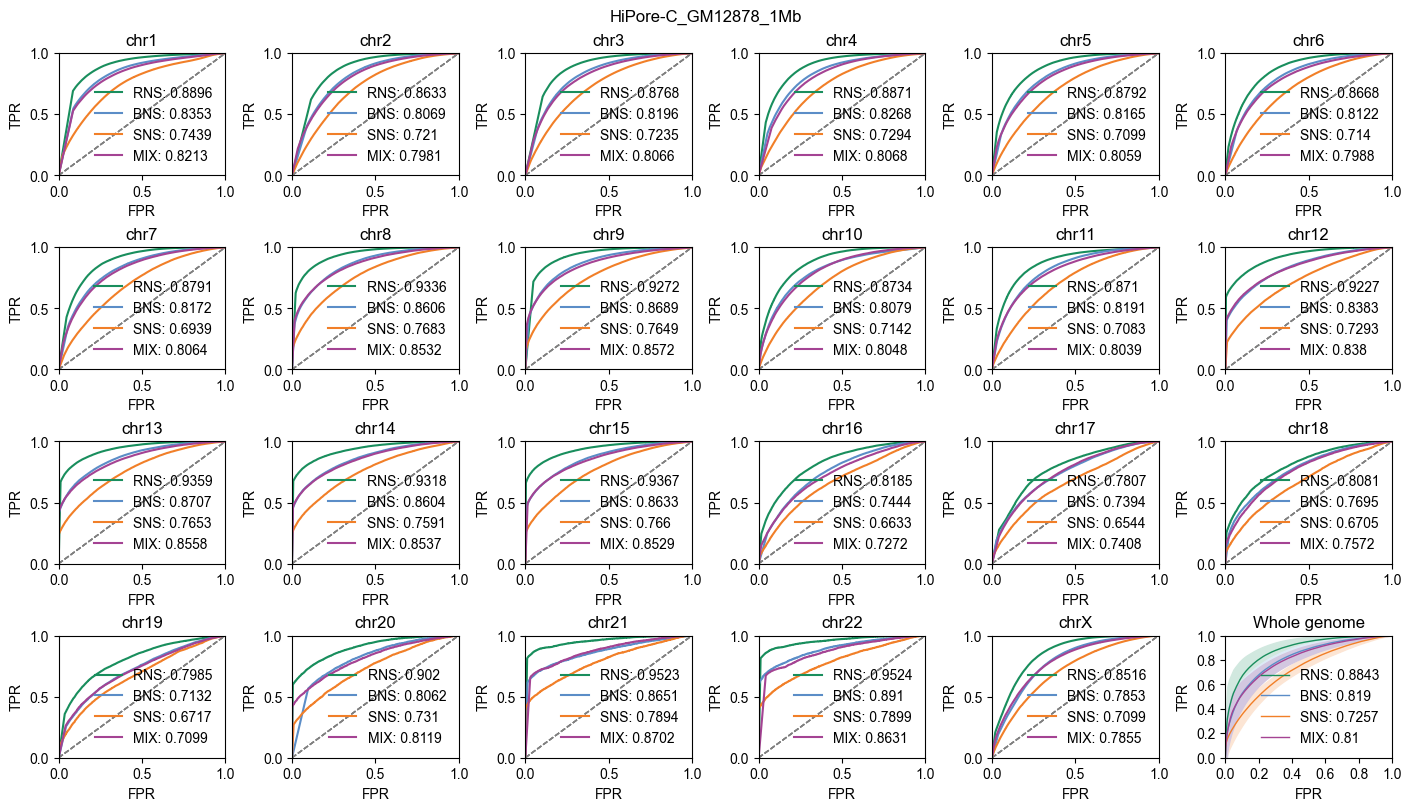

In [67]:
plot_ROC_curve('HiPore-C_GM12878_1Mb', res_dir, chroms)

100%|██████████| 23/23 [01:06<00:00,  2.91s/it]


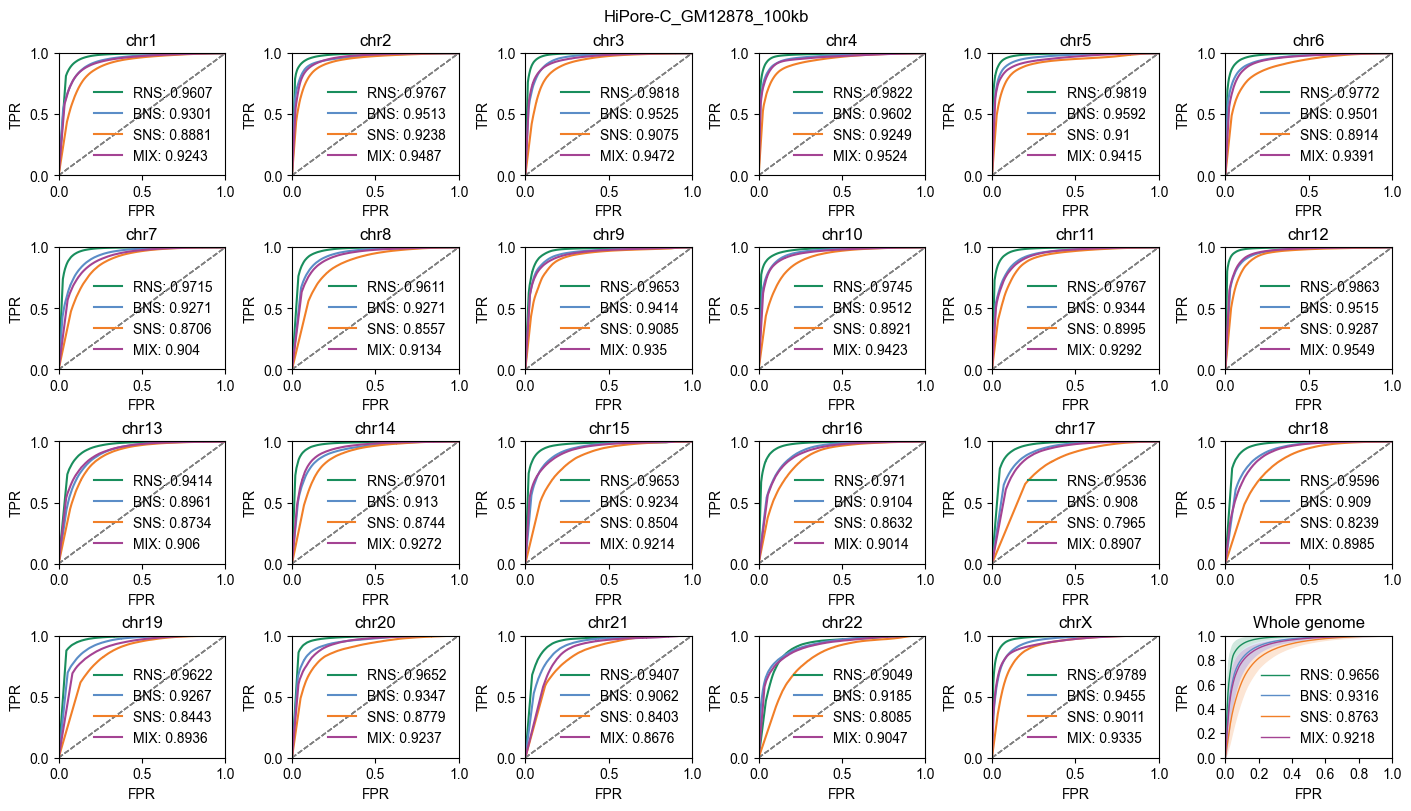

In [68]:
plot_ROC_curve('HiPore-C_GM12878_100kb', res_dir, chroms)

100%|██████████| 23/23 [00:59<00:00,  2.59s/it]


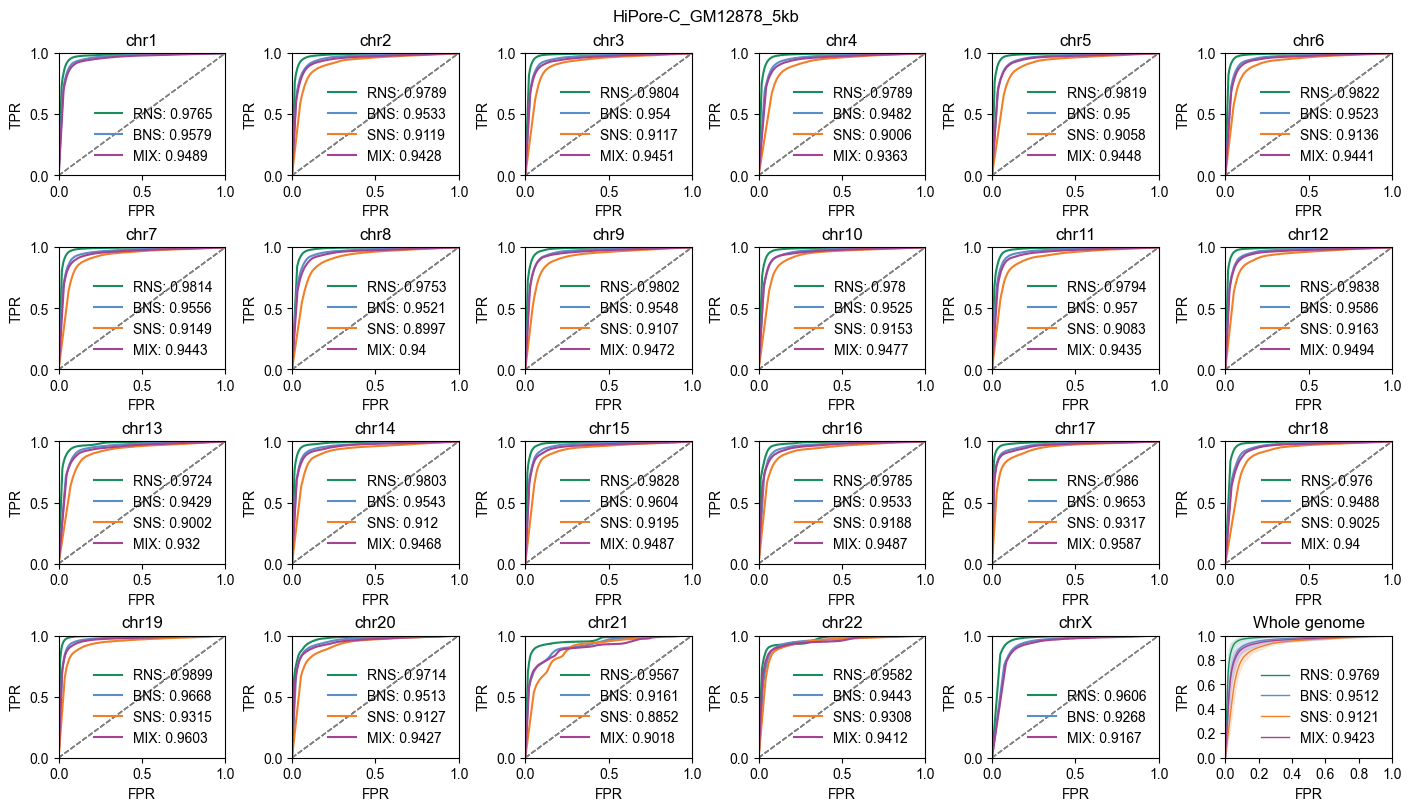

In [76]:
plot_ROC_curve('HiPore-C_GM12878_5kb', res_dir, chroms)